# Assessing the Global Military Carbon "Bootprint"
### A comparative analysis of military and conflict greenhouse-gas emissions against nation-states

**Author:** Reva Bhardwaj (working solo) · *Earth Data Science and Machine Learning — Final Project, Summer 2026*

---

## Question & hypothesis

Militaries are among the largest institutional consumers of fossil fuels on Earth, yet they are
largely **invisible in official climate statistics**: military emissions reporting to the UNFCCC has
been voluntary ever since military fuels were exempted from the Kyoto Protocol in 1997, and most
countries report nothing at all. Researchers call this the *military emissions gap*. This project
uses published estimates together with country-level emissions and spending data to put the military
footprint in context.

**Research question.** If the world's militaries were aggregated and treated as a single country,
where would they rank in annual greenhouse-gas (GHG) emissions compared to recognized national
emitters? And how do the attributable emissions of specific, acute conflicts compare to the annual
baseline emissions of mid-sized nation-states?

**Hypotheses.**

1. Aggregated global military emissions would place "Militaria" in the **top five** of the world's
   national emitters ranking.
2. National military expenditure scales **approximately linearly** (elasticity ≈ 1 on a log–log
   scale) with national GHG emissions across countries — bigger economies buy both more military
   and more emissions.
3. Acute conflicts release GHGs at a rate **comparable to the entire annual emissions of a
   mid-sized industrialized country** — i.e., a war is itself a significant "emitter country" while
   it lasts.

> This is a *contextual comparison*, not a counterfactual — we are ranking estimates against
> inventories to communicate scale, not claiming what emissions would be in a world without
> militaries.

## Data

| Dataset | What it provides | Access |
|---|---|---|
| **Our World in Data — CO₂ and GHG dataset** (`owid/co2-data`, compiled from the Global Carbon Project and Jones et al. 2024) | Country-level annual total GHG emissions (Mt CO₂e), used for the national rankings and comparisons. This is the same underlying data family that powers Climate Watch–style country rankings. | Downloaded automatically by this notebook from OWID's official GitHub mirror (cached locally after first run) |
| **SIPRI Military Expenditure Database** (constant 2021 US$ sheet, 2000–2022) | National military spending, used to test the spending↔emissions relationship and to allocate the global military footprint to countries. | Committed in this repo at `data/sipri-milex-constant-2021-usd.csv` (SIPRI distributes the original as an `.xlsx` behind a form — see `data/README.md` for provenance) |
| **SGR / CEOBS (2022), "Estimating the military's global greenhouse gas emissions"** | The headline scalar estimates: global military **total carbon footprint ≈ 2,750 Mt CO₂e ≈ 5.5 %** of global emissions (of which ≈ 500 Mt CO₂e is direct operational emissions). | Published values, cited inline |
| **IGGAW / Ecoaction (2025)** and **Costs of War, Brown University (Crawford 2019)** | Conflict case-study emissions: 3 years of Russia's war in Ukraine; US post-9/11 wars and Department of Defense totals. | Curated table committed at `data/conflict_war_emissions.csv` with a source column per row |

**Reproducibility.** Everything below runs top-to-bottom from a fresh kernel with only
`pandas`, `numpy`, `scipy` and `matplotlib`. All data is either in the repo or downloaded by the
notebook itself — no manual steps.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ---- one consistent, colorblind-checked style for every figure ----------
INK, SEC, MUTED = "#0b0b0b", "#52514e", "#898781"   # text
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, BLUE_DARK = "#2a78d6", "#184f95"              # accent: the military entity
RED = "#e34948"                                     # accent: active conflicts
GRAY_BAR = "#c3c2b7"                                # de-emphasized context bars

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "figure.dpi": 110, "font.size": 11,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlelocation": "left", "axes.titleweight": "bold",
    "axes.titlesize": 13, "axes.labelcolor": SEC,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.grid": False,
})

def style_grid(ax, axis="x"):
    '''Recessive hairline gridlines behind the marks.'''
    ax.grid(axis=axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

pd.set_option("display.float_format", lambda v: f"{v:,.1f}")
print("libraries loaded:", pd.__version__, np.__version__)

libraries loaded: 3.0.3 2.4.6


## Part 0 — Load and clean the country emissions data

The OWID CO₂/GHG dataset is one long "tidy" table: one row per (entity, year), with `total_ghg`
being total greenhouse-gas emissions in **Mt CO₂e** (CO₂ + CH₄ + N₂O, including land-use change,
100-year GWP). The cell below **downloads the file from OWID's GitHub mirror on first run** and
caches it under `data/` so re-runs are instant.

Cleaning steps:

1. Keep only the columns we need.
2. The table mixes real countries with aggregates (`World`, `Europe`, income groups, …).
   Real countries carry a **3-letter ISO code**, so we filter on that — but we keep the
   `World` row separately, since we need the global total as our denominator.

In [2]:
OWID_URL = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
owid_cache = Path("data/owid-co2-data.csv")

if owid_cache.exists():                       # cached from a previous run
    owid = pd.read_csv(owid_cache)
else:                                         # first run: download (~14 MB) and cache
    for attempt in range(3):                  # flaky-network retry
        try:
            owid = pd.read_csv(OWID_URL)
            break
        except Exception as err:
            print(f"download attempt {attempt + 1} failed ({err}); retrying...")
    else:
        raise RuntimeError("could not download the OWID dataset after 3 attempts")
    owid_cache.parent.mkdir(exist_ok=True)
    owid.to_csv(owid_cache, index=False)

owid = owid[["country", "year", "iso_code", "population", "total_ghg", "co2"]]
print(f"{len(owid):,} rows · {owid.country.nunique()} entities · years {owid.year.min()}–{owid.year.max()}")
owid.tail(3)

50,411 rows · 254 entities · years 1750–2024


,country,year,iso_code,population,total_ghg,co2
50408,Zimbabwe,2022,ZWE,"16,069,061.0",29.9,12.2
50409,Zimbabwe,2023,ZWE,"16,340,829.0",31.0,13.4
50410,Zimbabwe,2024,ZWE,"16,634,366.0",31.1,13.7


In [3]:
# Split real countries from aggregates, and pull out the world total we rank against.
is_country = owid.iso_code.notna() & (owid.iso_code.str.len() == 3)

LATEST = int(owid.loc[owid.total_ghg.notna(), "year"].max())
countries = (owid[is_country & (owid.year == LATEST) & owid.total_ghg.notna()]
             .loc[:, ["country", "iso_code", "total_ghg", "population"]]
             .sort_values("total_ghg", ascending=False)
             .reset_index(drop=True))
WORLD_GHG = float(owid.loc[(owid.country == "World") & (owid.year == LATEST), "total_ghg"].iloc[0])

print(f"latest year with GHG data: {LATEST}")
print(f"world total GHG {LATEST}: {WORLD_GHG:,.0f} Mt CO2e across {len(countries)} countries")
countries.head(10)

latest year with GHG data: 2024
world total GHG 2024: 54,433 Mt CO2e across 199 countries


,country,iso_code,total_ghg,population
0,China,CHN,"14,107.0","1,419,321,284.0"
1,United States,USA,"6,054.3","345,426,566.0"
2,India,IND,"4,262.4","1,450,935,785.0"
3,Brazil,BRA,"2,804.4","211,998,565.0"
4,Russia,RUS,"2,729.2","144,820,421.0"
5,Indonesia,IDN,"1,902.5","283,487,933.0"
6,Iran,IRN,"1,012.2","91,567,737.0"
7,Japan,JPN,"1,007.2","123,753,041.0"
8,Saudi Arabia,SAU,821.8,"33,962,751.0"
9,Canada,CAN,802.7,"39,742,429.0"


## Part 1 — If the world's militaries were a country, where would they rank?

There is no measured global military inventory (that is exactly the military emissions gap), so we
use the best published estimate: **Scientists for Global Responsibility & CEOBS (2022)** combined
per-soldier operational emissions with supply-chain multipliers to estimate the world's militaries at

$$E_\text{military} \approx 2{,}750\ \text{Mt CO}_2\text{e} \approx 5.5\%\ \text{of global emissions}$$

of which ≈ 500 Mt CO₂e is *direct operational* emissions (bases and fuel), the rest being military
equipment supply chains and other indirect sources. We inject two variants of this "country" into
the latest national ranking:

* **central estimate** — the published 2,750 Mt CO₂e value;
* **share-scaled** — 5.5 % applied to the *latest* world total, i.e. assuming the military share
  held constant (the published estimate is based on ~2019–2021 activity data).

As a lower bound we also rank the operational-only 500 Mt.

In [4]:
MIL_TOTAL_PUBLISHED = 2750.0            # Mt CO2e, SGR/CEOBS (2022) central estimate
MIL_SHARE           = 0.055             # 5.5% of global GHG
MIL_OPERATIONAL     = 500.0             # Mt CO2e, direct operational emissions only

mil_scaled = MIL_SHARE * WORLD_GHG      # the 5.5% share applied to the latest world total

def rank_within_countries(value_mt):
    '''1-based rank this emissions value would take among national emitters.'''
    return int((countries.total_ghg > value_mt).sum()) + 1

for label, val in [("published central (2,750 Mt)", MIL_TOTAL_PUBLISHED),
                   (f"5.5% of {LATEST} world total", mil_scaled),
                   ("operational only (500 Mt)", MIL_OPERATIONAL)]:
    print(f"{label:32s} -> {val:7,.0f} Mt CO2e -> rank #{rank_within_countries(val)}")

MIL_RANK = rank_within_countries(mil_scaled)

published central (2,750 Mt)     ->   2,750 Mt CO2e -> rank #5
5.5% of 2024 world total         ->   2,994 Mt CO2e -> rank #4
operational only (500 Mt)        ->     500 Mt CO2e -> rank #19


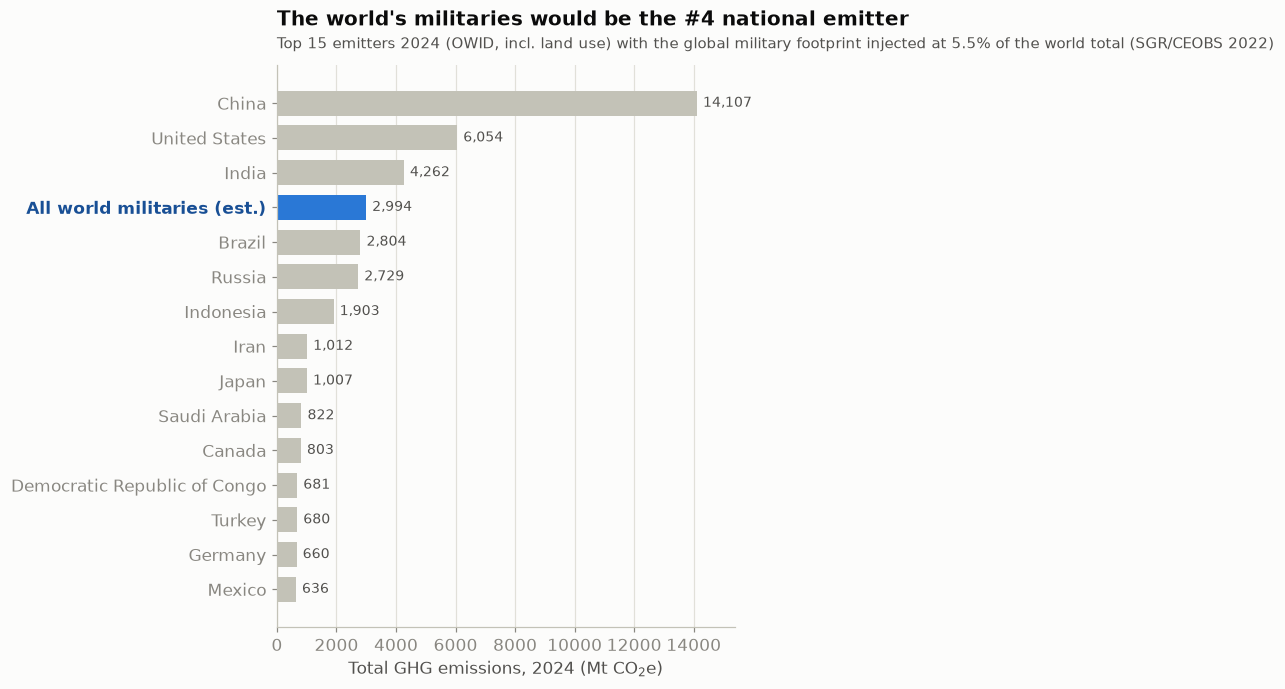

In [5]:
# ---- Figure 1: the ranking, with the military "country" injected ------------
TOP_N = 15
military_row = pd.DataFrame({"country": [f"All world militaries (est.)"],
                             "total_ghg": [mil_scaled]})
ranking = (pd.concat([countries[["country", "total_ghg"]], military_row])
           .sort_values("total_ghg", ascending=False)
           .head(TOP_N)[::-1])                      # reversed: biggest bar on top
is_mil = ranking.country.str.startswith("All world")

fig, ax = plt.subplots(figsize=(9, 6.4))
bars = ax.barh(ranking.country, ranking.total_ghg,
               color=[BLUE if m else GRAY_BAR for m in is_mil], height=0.72)
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in ranking.total_ghg],
             padding=4, fontsize=9, color=SEC)

style_grid(ax, "x")
ax.set_xlabel(f"Total GHG emissions, {LATEST} (Mt CO$_2$e)")
ax.set_title(f"The world's militaries would be the #{MIL_RANK} national emitter",
             pad=26)
ax.text(0, 1.03, f"Top {TOP_N} emitters {LATEST} (OWID, incl. land use) with the global military "
                 f"footprint injected at 5.5% of the world total (SGR/CEOBS 2022)",
        transform=ax.transAxes, fontsize=9.5, color=SEC)
for lbl, m in zip(ax.get_yticklabels(), is_mil):
    if m:
        lbl.set_color(BLUE_DARK); lbl.set_fontweight("bold")
ax.margins(x=0.09)
fig.tight_layout()
plt.show()

**Reading Figure 1.** The aggregated militaries land in **4th place** at the share-scaled
estimate (~3,000 Mt CO₂e) and 5th at the published 2,750 Mt — in both cases **ahead of Russia**,
the largest single-country fossil-fuel exporter. (At the lower estimate Brazil edges ahead, but
only because Brazil's inventory includes enormous land-use-change emissions; on fossil emissions
alone the militaries clear it easily.) Even the most conservative slice — the 500 Mt CO₂e of
*direct operational* emissions only, ignoring all supply chains — still ranks **#19**, out-emitting
about 180 of the world's ~200 countries. **Hypothesis 1 is supported** and robust to the choice of
estimate.

## Part 2 — Does military spending scale with national emissions?

Since militaries do not report emissions, **military expenditure is the observable proxy** — it is
measured consistently by SIPRI for ~170 countries. Before using spending to allocate emissions
(Part 3), we should understand how spending relates to a country's carbon output at all.

The SIPRI sheet is *real-world messy*, which makes it a good cleaning exercise:

* it is **wide** (one column per year) and must be melted to tidy long format;
* missing data is encoded as `...`, and `xxx` marks years where a state did not exist;
* one country name arrives **mojibake'd** (`T?rkiye`) from the original file's encoding;
* SIPRI and OWID spell several countries differently (`United States of America` vs
  `United States`, `Korea, South` vs `South Korea`, …), so we harmonize names before merging.

Values are **millions of constant (2021) US dollars**, so spending is comparable across years.

In [6]:
sipri_raw = pd.read_csv("data/sipri-milex-constant-2021-usd.csv",
                        na_values=["...", "xxx"])        # sentinel values -> NaN

# --- tidy: wide -> long ------------------------------------------------------
milex = (sipri_raw
         .rename(columns={"Country": "country"})
         .melt(id_vars="country", var_name="year", value_name="milex_musd")
         .assign(year=lambda d: d.year.astype(int),
                 country=lambda d: d.country.str.strip()))

# --- harmonize country names to OWID's spelling ------------------------------
NAME_FIXES = {
    "United States of America": "United States",
    "Korea, South": "South Korea",
    "Korea, North": "North Korea",
    "T?rkiye": "Turkey",                     # mojibake in the source file
    "Congo, DR": "Democratic Republic of Congo",
    "Congo, Republic": "Congo",
    "Gambia, The": "Gambia",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Timor Leste": "East Timor",
    "Viet Nam": "Vietnam",
}
milex["country"] = milex.country.replace(NAME_FIXES)

MERGE_YEAR = 2022                            # latest year covered by both datasets
milex22 = milex.query("year == @MERGE_YEAR").dropna(subset=["milex_musd"])

ghg22 = (owid[is_country & (owid.year == MERGE_YEAR)]
         [["country", "total_ghg", "population"]].dropna(subset=["total_ghg"]))
merged = milex22.merge(ghg22, on="country", how="inner")

unmatched = sorted(set(milex22.country) - set(merged.country))
print(f"{len(milex22)} countries with {MERGE_YEAR} spending -> {len(merged)} matched to emissions")
print("unmatched (no OWID country row):", unmatched)
assert set(milex22.nlargest(15, 'milex_musd').country) <= set(merged.country), \
    "a top-15 military spender failed to merge!"
merged.nlargest(5, "milex_musd")

153 countries with 2022 spending -> 152 matched to emissions
unmatched (no OWID country row): ['Kosovo']


,country,year,milex_musd,total_ghg,population
59,United States,2022,"811,591.2","6,201.5","341,534,041.0"
80,China,2022,"297,999.0","13,446.9","1,425,179,562.0"
76,India,2022,"80,955.8","3,870.0","1,425,423,209.0"
150,Saudi Arabia,2022,"73,041.5",795.2,"32,175,351.0"
118,Russia,2022,"71,981.1","2,600.8","145,579,889.0"


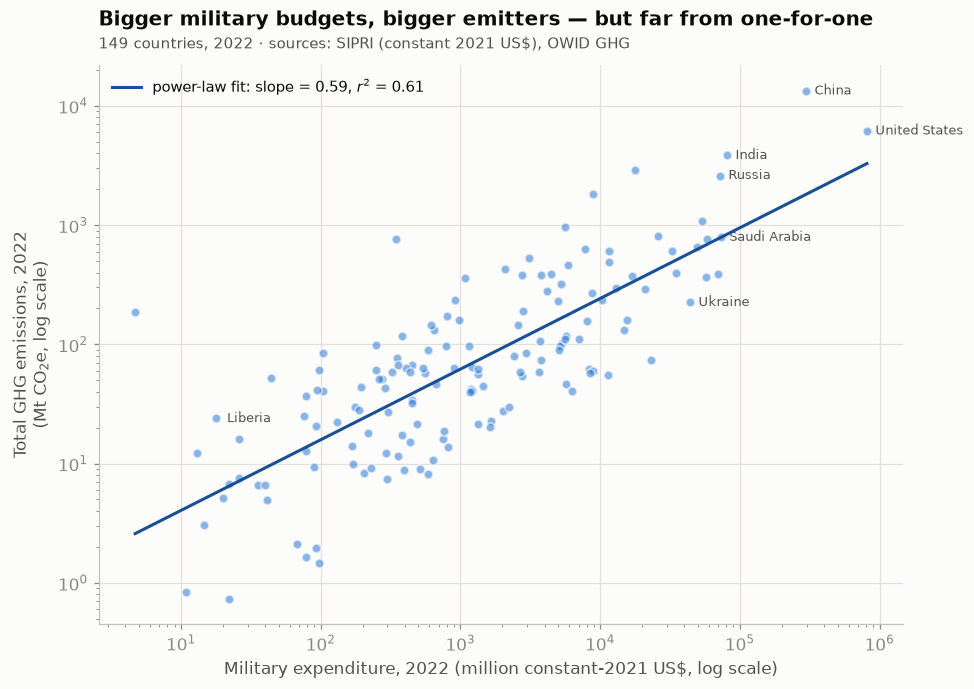

log-log slope (elasticity): 0.59 ± 0.08  (r = 0.78)


In [7]:
# ---- Figure 2: military spending vs national GHG, log-log + fitted power law ----
x, y = merged.milex_musd.values, merged.total_ghg.values
ok = (x > 0) & (y > 0)
fit = stats.linregress(np.log10(x[ok]), np.log10(y[ok]))

fig, ax = plt.subplots(figsize=(9, 6.4))
ax.scatter(x, y, s=34, color=BLUE, alpha=0.55, edgecolors=SURFACE, linewidths=1.2, zorder=3)
xs = np.logspace(np.log10(x[ok].min()), np.log10(x[ok].max()), 100)
ax.plot(xs, 10**fit.intercept * xs**fit.slope, color=BLUE_DARK, lw=2, zorder=4,
        label=f"power-law fit: slope = {fit.slope:.2f}, $r^2$ = {fit.rvalue**2:.2f}")

ax.set_xscale("log"); ax.set_yscale("log")
style_grid(ax, "both")
for name, dx in [("United States", 1.15), ("China", 1.15), ("India", 1.15),
                 ("Russia", 1.15), ("Ukraine", 1.15), ("Saudi Arabia", 1.15),
                 ("Iceland", 1.2), ("Liberia", 1.2)]:
    row = merged.loc[merged.country == name]
    if len(row):
        ax.annotate(name, (row.milex_musd.iloc[0] * dx, row.total_ghg.iloc[0]),
                    fontsize = 8.5, color=SEC, va="center")

ax.set_xlabel("Military expenditure, 2022 (million constant-2021 US$, log scale)")
ax.set_ylabel("Total GHG emissions, 2022\n(Mt CO$_2$e, log scale)")
ax.set_title("Bigger military budgets, bigger emitters — but far from one-for-one", pad=26)
ax.text(0, 1.03, f"{ok.sum()} countries, 2022 · sources: SIPRI (constant 2021 US$), OWID GHG",
        transform=ax.transAxes, fontsize=9.5, color=SEC)
ax.legend(frameon=False, loc="upper left", fontsize=9.5)
fig.tight_layout()
plt.show()

print(f"log-log slope (elasticity): {fit.slope:.2f} ± {2*fit.stderr:.2f}  (r = {fit.rvalue:.2f})")

**Reading Figure 2.** Across ~150 countries, military spending and national GHG emissions are
strongly correlated in log space (r ≈ 0.78, r² ≈ 0.61) — but the **power-law slope is only ≈ 0.6,
clearly sublinear**: a 10× larger military budget is associated with only a ~4× (10^0.59) larger
national footprint. **Hypothesis 2 is rejected in its strict (elasticity ≈ 1) form.** This is
*not* a causal claim — both quantities track the overall size of an economy — but the sublinearity
carries a real warning for what follows: emissions per military dollar apparently *fall* as budgets
grow (the biggest spenders are rich countries with capital- and salary-heavy militaries), so
allocating the global military footprint **proportionally to spending will tend to overstate the
top spenders** and understate fuel-intensive, lower-cost forces. Keep that in mind as we do exactly
that allocation next — alongside a second, independent method.

## Part 3 — Whose bootprint is it? Allocating the global estimate to countries

We estimate individual countries' military footprints two independent ways, then compare them —
because when the true number is unreported, the *spread between methods* is the honest error bar.

**Method A — spending share.** Allocate the SGR/CEOBS global *total* footprint in proportion to
each country's share of world military spending:

$$E_i^{(A)} = 2{,}750 \times \frac{M_i}{\sum_j M_j}\quad[\text{Mt CO}_2\text{e}]$$

**Method B — US intensity transfer.** The Pentagon is the only military with a published long-run
emissions series (Crawford 2019: **59 Mt CO₂e in FY2017**). Dividing by US spending that year gives
an *operational* emissions intensity (t CO₂e per constant-2021 $M), which we transfer to other
countries' budgets:

$$E_i^{(B)} = \underbrace{\frac{59\ \text{Mt}}{M_{US,2017}}}_{\text{intensity}} \times M_i$$

Method A captures the *full* footprint (supply chains included) but assumes every dollar is equally
carbon-intensive; Method B is grounded in a real measured inventory but covers *operations only*
and assumes other militaries burn fuel like the US one does. Reality sits in between.

In [8]:
top10 = merged.nlargest(10, "milex_musd").copy()

# Method A: share of world spending x published global total footprint
world_milex = milex22.milex_musd.sum()
top10["est_A"] = MIL_TOTAL_PUBLISHED * top10.milex_musd / world_milex

# Method B: US DOD operational intensity (FY2017) x spending
US_DOD_2017_MT = 59.0
us_milex_2017 = float(milex.query("country == 'United States' and year == 2017").milex_musd.iloc[0])
intensity = US_DOD_2017_MT / us_milex_2017          # Mt CO2e per constant-2021 $M
top10["est_B"] = intensity * top10.milex_musd

top10["share_of_national_A"] = 100 * top10.est_A / top10.total_ghg
print(f"world military spending 2022 (dataset sum): {world_milex/1e6:,.2f} trillion constant-2021 $")
print(f"US DOD operational intensity: {intensity*1e6:.1f} t CO2e per constant-2021 $M")
top10[["country", "milex_musd", "est_A", "est_B", "share_of_national_A"]].round(1)

world military spending 2022 (dataset sum): 2.15 trillion constant-2021 $
US DOD operational intensity: 82.5 t CO2e per constant-2021 $M


,country,milex_musd,est_A,est_B,share_of_national_A
59,United States,"811,591.2","1,039.6",67.0,16.8
80,China,"297,999.0",381.7,24.6,2.8
76,India,"80,955.8",103.7,6.7,2.7
150,Saudi Arabia,"73,041.5",93.6,6.0,11.8
118,Russia,"71,981.1",92.2,5.9,3.5
139,United Kingdom,"69,998.7",89.7,5.8,22.9
126,Germany,"57,807.7",74.1,4.8,9.7
125,France,"56,999.7",73.0,4.7,19.7
81,Japan,"53,946.5",69.1,4.5,6.4
82,South Korea,"49,618.3",63.6,4.1,9.8


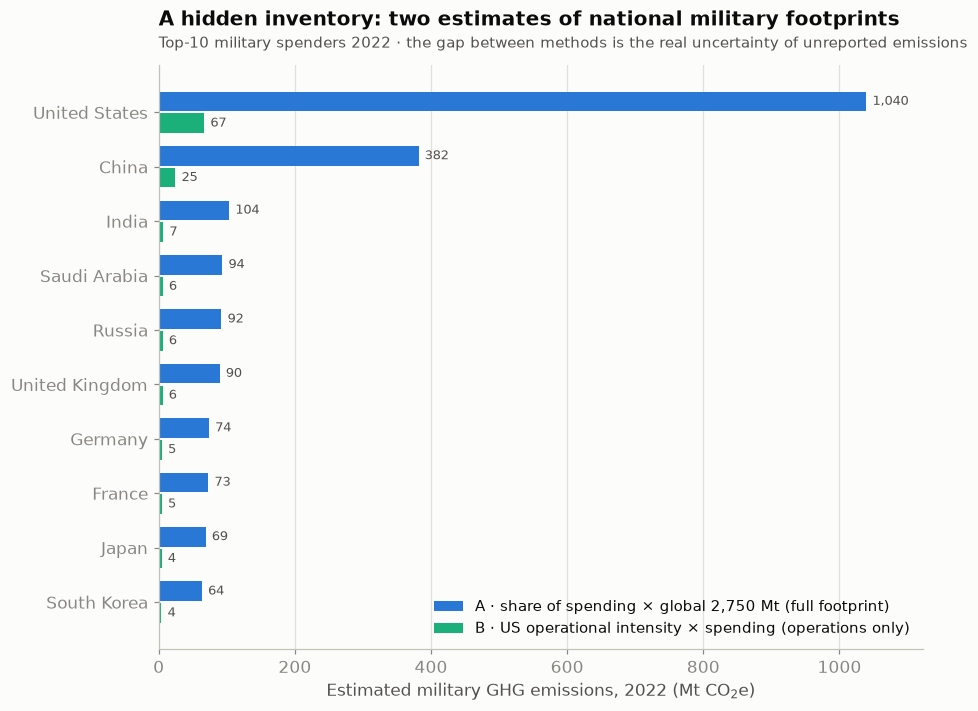

In [9]:
# ---- Figure 3: two estimates of national military footprints, top-10 spenders ----
d = top10[::-1]                                     # biggest on top
yy = np.arange(len(d))
H = 0.36

fig, ax = plt.subplots(figsize=(9, 6.6))
bA = ax.barh(yy + H/2 + 0.02, d.est_A, height=H, color=BLUE,
             label="A · share of spending × global 2,750 Mt (full footprint)")
bB = ax.barh(yy - H/2 - 0.02, d.est_B, height=H, color="#1baf7a",
             label="B · US operational intensity × spending (operations only)")
ax.bar_label(bA, labels=[f"{v:,.0f}" for v in d.est_A], padding=4, fontsize=8.5, color=SEC)
ax.bar_label(bB, labels=[f"{v:,.0f}" for v in d.est_B], padding=4, fontsize=8.5, color=SEC)

ax.set_yticks(yy, d.country)
style_grid(ax, "x")
ax.set_xlabel("Estimated military GHG emissions, 2022 (Mt CO$_2$e)")
ax.set_title("A hidden inventory: two estimates of national military footprints", pad=26)
ax.text(0, 1.03, "Top-10 military spenders 2022 · the gap between methods is the real "
                 "uncertainty of unreported emissions", transform=ax.transAxes,
        fontsize=9.5, color=SEC)
ax.legend(frameon=False, loc="lower right", fontsize=9.5)
ax.margins(x=0.08)
fig.tight_layout()
plt.show()

**Reading Figure 3.** The two methods disagree by roughly a factor of ~10–15 — and that gap *is*
the finding. Method B (green) prices only the fuel-and-bases operations that the Pentagon actually
reports; Method A (blue) spreads the full supply-chain-inclusive global estimate by budget share.
Under Method A the **US military alone would carry ≈ 1,000 Mt CO₂e (roughly 17 % of the entire US
inventory)** — almost certainly an overestimate, since US spending is unusually capital- and
salary-heavy per soldier. Under Method B China's and India's footprints are almost certainly
*under*estimated, since their militaries are more personnel- and fuel-intensive per dollar. The
truth lies between the bars — and the fact that a factor-of-ten uncertainty persists for some of
the world's largest institutional emitters is precisely why researchers demand mandatory military
emissions reporting under the UNFCCC.

## Part 4 — Conflict case studies: wars as temporary "emitter countries"

Baseline military footprints are only part of the story — **active conflicts compress large
emissions into short windows**: fuel for operations, ammunition, landscape fires, destroyed energy
infrastructure, displacement, and eventually reconstruction (cement and steel are extremely
carbon-intensive). We compare published conflict totals, **annualized** ($E/\text{duration}$),
against the annual national inventories of mid-sized countries from the same OWID table.

Scope caveat, stated up front: war-accounting studies (IGGAW, Costs of War) count categories that
national inventories don't (e.g. *future* reconstruction, fires), so these are indicative
comparisons of scale, not like-for-like inventory entries.

In [10]:
conflicts = pd.read_csv("data/conflict_war_emissions.csv")
conflicts["mt_per_year"] = conflicts.mtco2e / conflicts.duration_years
conflicts[["case", "period", "mtco2e", "duration_years", "mt_per_year", "source"]].round(1)

,case,period,mtco2e,duration_years,mt_per_year,source
0,Russia's war in Ukraine — all war-attributable,Feb 2022 – Feb 2025,230.0,3.0,76.7,Initiative on GHG Accounting of War (IGGAW) / ...
1,Russia's war in Ukraine — direct warfare only,Feb 2022 – Feb 2025,82.1,3.0,27.4,Initiative on GHG Accounting of War (IGGAW) / ...
2,US post-9/11 wars — war-related emissions,2001–2018,440.0,18.0,24.4,"Crawford (2019), Costs of War Project, Brown U..."
3,US Department of Defense — total,2001–2017,"1,212.0",17.0,71.3,"Crawford (2019), Costs of War Project, Brown U..."
4,US Department of Defense — one year,FY2017,59.0,1.0,59.0,"Crawford (2019), Costs of War Project, Brown U..."


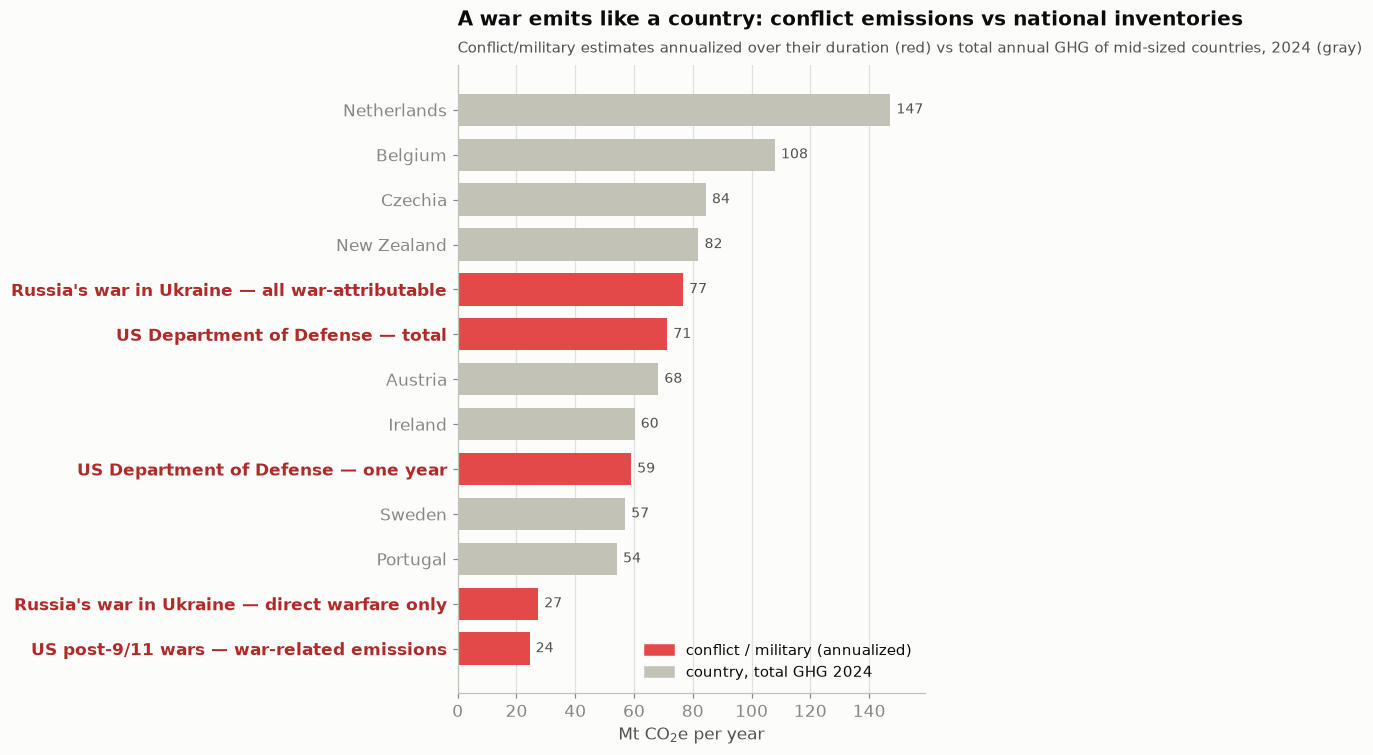

In [11]:
# ---- Figure 4: annualized conflict emissions vs whole countries' annual GHG ----
COMPARATORS = ["Netherlands", "Czechia", "Belgium", "Austria", "Portugal",
               "Sweden", "Ireland", "New Zealand"]
comp = (countries[countries.country.isin(COMPARATORS)]
        [["country", "total_ghg"]]
        .rename(columns={"total_ghg": "mt_per_year"})
        .assign(kind="country"))
conf = (conflicts[["case", "mt_per_year"]]
        .rename(columns={"case": "country"})
        .assign(kind="conflict"))

combo = (pd.concat([conf, comp])
         .sort_values("mt_per_year")
         .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9.5, 7))
bars = ax.barh(combo.country, combo.mt_per_year,
               color=[RED if k == "conflict" else GRAY_BAR for k in combo.kind],
               height=0.72)
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in combo.mt_per_year],
             padding=4, fontsize=9, color=SEC)
for lbl, k in zip(ax.get_yticklabels(), combo.kind):
    if k == "conflict":
        lbl.set_color("#b02a2a"); lbl.set_fontweight("bold")

style_grid(ax, "x")
ax.set_xlabel("Mt CO$_2$e per year")
ax.set_title("A war emits like a country: conflict emissions vs national inventories", pad=26)
ax.text(0, 1.02, f"Conflict/military estimates annualized over their duration (red) vs total "
                 f"annual GHG of mid-sized countries, {LATEST} (gray)",
        transform=ax.transAxes, fontsize=9.5, color=SEC)
ax.legend(handles=[plt.Rectangle((0,0),1,1,color=RED, label="conflict / military (annualized)"),
                   plt.Rectangle((0,0),1,1,color=GRAY_BAR, label=f"country, total GHG {LATEST}")],
          frameon=False, loc="lower right", fontsize=9.5)
ax.margins(x=0.08)
fig.tight_layout()
plt.show()

**Reading Figure 4.** Every red bar is an event, not a place — yet each one out-emits real
countries. Three years of Russia's war in Ukraine released **230 Mt CO₂e (~77 Mt CO₂e/yr)** — a
rate above Austria's or Portugal's entire annual inventory; the IGGAW authors note the cumulative
total equals the combined annual emissions of Austria, Hungary, Czechia and Slovakia. The
Pentagon's *routine peacetime* year (FY2017, 59 Mt) alone out-emits Sweden or Portugal, and the
post-9/11 wars ran an extra ~24 Mt CO₂e/yr "emitter" on top of that for nearly two decades. Other recent conflicts show
the same pattern (studies of the war in Gaza estimate reconstruction alone at tens of Mt CO₂e —
we exclude it here as the estimates are still in flux). **Hypothesis 3 is supported.**

## Conclusions

1. **Militaries would rank 4th–5th among the world's emitters.** At the SGR/CEOBS estimate of
   5.5 % of global emissions (≈ 2,750–3,000 Mt CO₂e), the aggregated world military out-emits every
   country except China, the US, India — and, at the low end, Brazil's deforestation-inflated
   total — while clearly out-emitting Russia. Even counting only direct operational emissions
   (500 Mt), it remains the ~19th-largest "country". *(Hypothesis 1 ✓)*
2. **Spending tracks emissions strongly but sublinearly** (r ≈ 0.78, log–log slope ≈ 0.6 across
   ~150 countries): a 10× bigger military budget associates with only a ~4× bigger national
   footprint, so the strict "linear scaling" hypothesis is rejected. Budget share therefore works
   only as a rough, first-order allocation key — and the factor-of-ten spread between our two
   allocation methods for individual countries shows how much uncertainty the reporting gap
   creates. *(Hypothesis 2 ✗ in strict form — the honest result)*
3. **Acute conflicts emit at the rate of whole industrialized countries** — Russia's war in
   Ukraine at ~77 Mt CO₂e/yr exceeds Austria's annual inventory; a routine Pentagon year exceeds
   Sweden's. *(Hypothesis 3 ✓)*

The common thread is the **military emissions gap**: for an activity cluster the size of the
world's 4th-largest emitter, we are still doing arithmetic with one published inventory (the US)
and NGO estimates. Mandatory, transparent UNFCCC reporting of military emissions would turn this
notebook's estimates into measurements.

## Limitations

* The 5.5 % / 2,750 Mt figure is itself an estimate built from per-soldier factors and supply-chain
  multipliers; its authors label it "likely conservative", but its uncertainty is unquantified.
* Both allocation methods in Part 3 assume emissions scale with spending; differences in force
  structure, fuel mix and procurement break that assumption in known directions.
* Conflict accounting (IGGAW) includes categories national inventories exclude (future
  reconstruction, landscape fires), so Figure 4 compares *scales*, not identical scopes.
* SIPRI spending is the *budget* proxy; off-budget and covert military activity is invisible to it.
* The correlation in Part 2 is confounded by economy size; it supports allocation, not causality.

## References

* Parkinson, S. & Cottrell, L. (2022). *Estimating the military's global greenhouse gas emissions.*
  Scientists for Global Responsibility / Conflict and Environment Observatory.
  [ceobs.org](https://ceobs.org/estimating-the-militarys-global-greenhouse-gas-emissions/)
* Initiative on GHG Accounting of War / Ecoaction (2025). *Climate damage caused by Russia's war in
  Ukraine, 24 Feb 2022 – 23 Feb 2025.* [en.ecoaction.org.ua](https://en.ecoaction.org.ua/climate-damage-3-years-numbers.html)
* Crawford, N. C. (2019). *Pentagon Fuel Use, Climate Change, and the Costs of War.* Costs of War
  Project, Brown University. [costsofwar.watson.brown.edu](https://costsofwar.watson.brown.edu/paper/pentagon-fuel-use-climate-change-and-costs-war)
* SIPRI (2023). *SIPRI Military Expenditure Database.* [sipri.org/databases/milex](https://www.sipri.org/databases/milex)
* Our World in Data (2025). *CO₂ and Greenhouse Gas Emissions* dataset (Global Carbon Project;
  Jones et al. 2024). [github.com/owid/co2-data](https://github.com/owid/co2-data)
* The Military Emissions Gap project: [militaryemissions.org](https://militaryemissions.org/)